# R2-Dreamer Habitat Baseline — Training Analysis

**Goal:** Visualize training metrics from the R2-Dreamer no-goal baseline on HM3D ObjectNav.

| Property | Value |
|----------|-------|
| Agent | R2-Dreamer (JAX, no goal conditioning) |
| Environment | HM3D ObjectNav (4 actions, 64x64 RGB) |
| Reward | geodesic_delta |
| Input | `output/r2dreamer-habitat-baseline/*/metrics.csv` |

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})

In [2]:
# --- Load metrics CSV ---
# Point this to whichever run you want to analyze
RUN_DIR = Path("../../../output/r2dreamer-habitat-baseline/sanity-50k")
csv_path = RUN_DIR / "metrics.csv"
assert csv_path.exists(), f"Not found: {csv_path}"

df = pd.read_csv(csv_path)
print(f"Loaded {len(df)} rows from {csv_path}")
df.head(10)

Loaded 2191 rows from ../../../output/r2dreamer-habitat-baseline/sanity-50k/metrics.csv


,step,metric,value
0,250,loss/barlow,292.359558
1,250,loss/con,0.027927
2,250,loss/dyn,6.253784
3,250,loss/policy,-0.052188
4,250,loss/rep,6.253784
5,250,loss/repval,2.591949
6,250,loss/rew,0.356756
7,250,loss/value,1.336004
8,250,total_loss,23.943222
9,499,episode/reward,1.224541


In [3]:
def extract_metric(df, name):
    """Extract a single metric as (step, value) arrays."""
    sub = df[df["metric"] == name]
    return sub["step"].values, sub["value"].values.astype(float)

## Episode Metrics

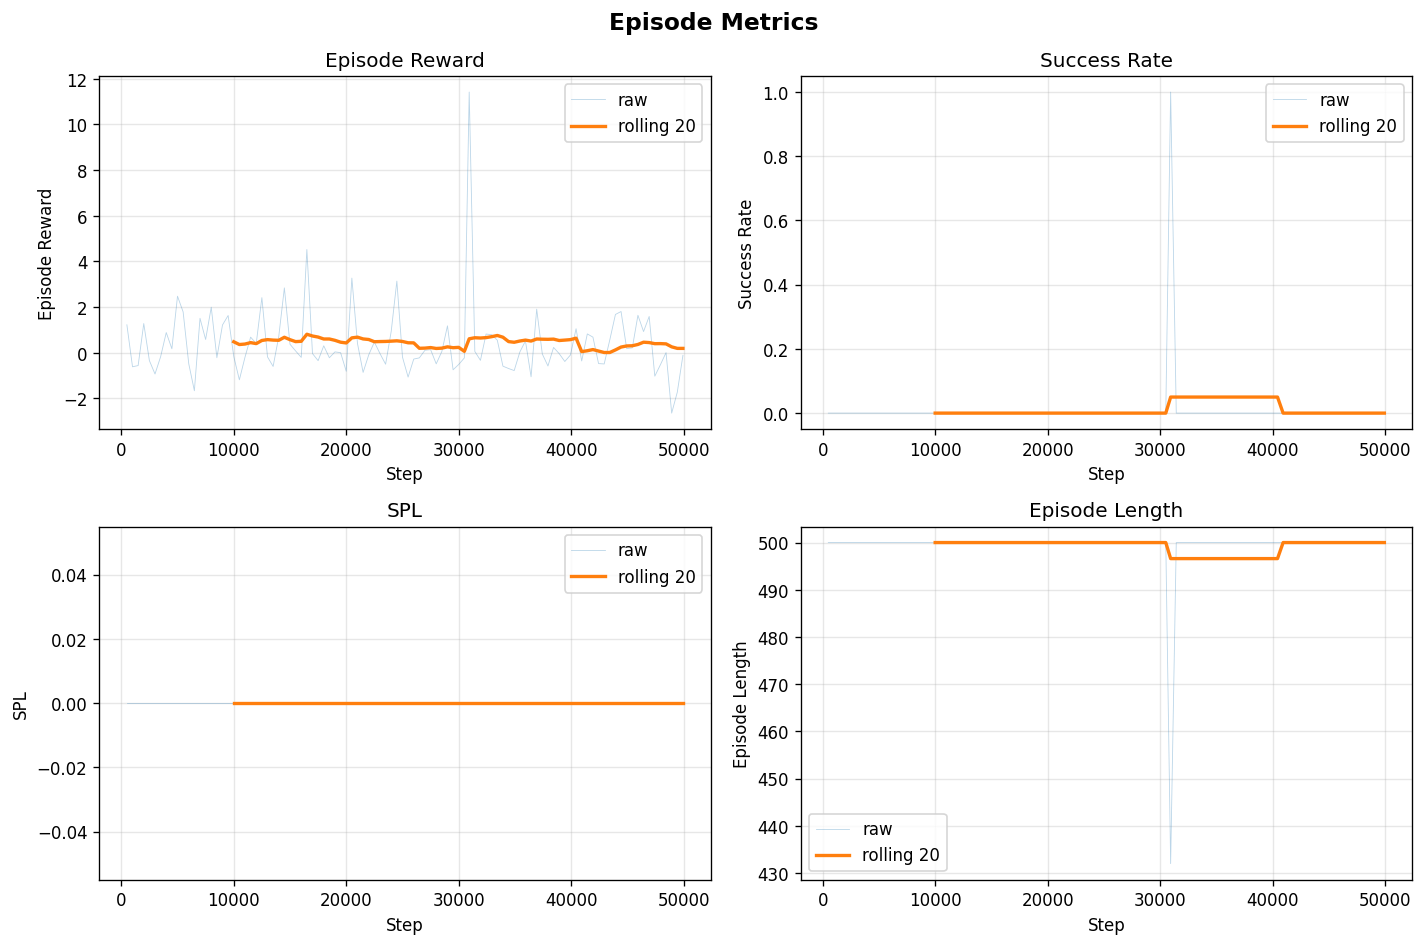

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, metric, label in zip(
    axes.flat,
    ["episode/reward", "episode/success", "episode/spl", "episode/steps"],
    ["Episode Reward", "Success Rate", "SPL", "Episode Length"],
):
    steps, vals = extract_metric(df, metric)
    if len(steps) == 0:
        ax.set_title(f"{label} (no data)")
        continue
    ax.plot(steps, vals, alpha=0.3, linewidth=0.5, label="raw")
    # Rolling average over last 20 episodes
    if len(vals) >= 20:
        window = min(20, len(vals))
        rolling = pd.Series(vals).rolling(window).mean().values
        ax.plot(steps, rolling, linewidth=2, label=f"rolling {window}")
    ax.set_xlabel("Step")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Episode Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Training Losses

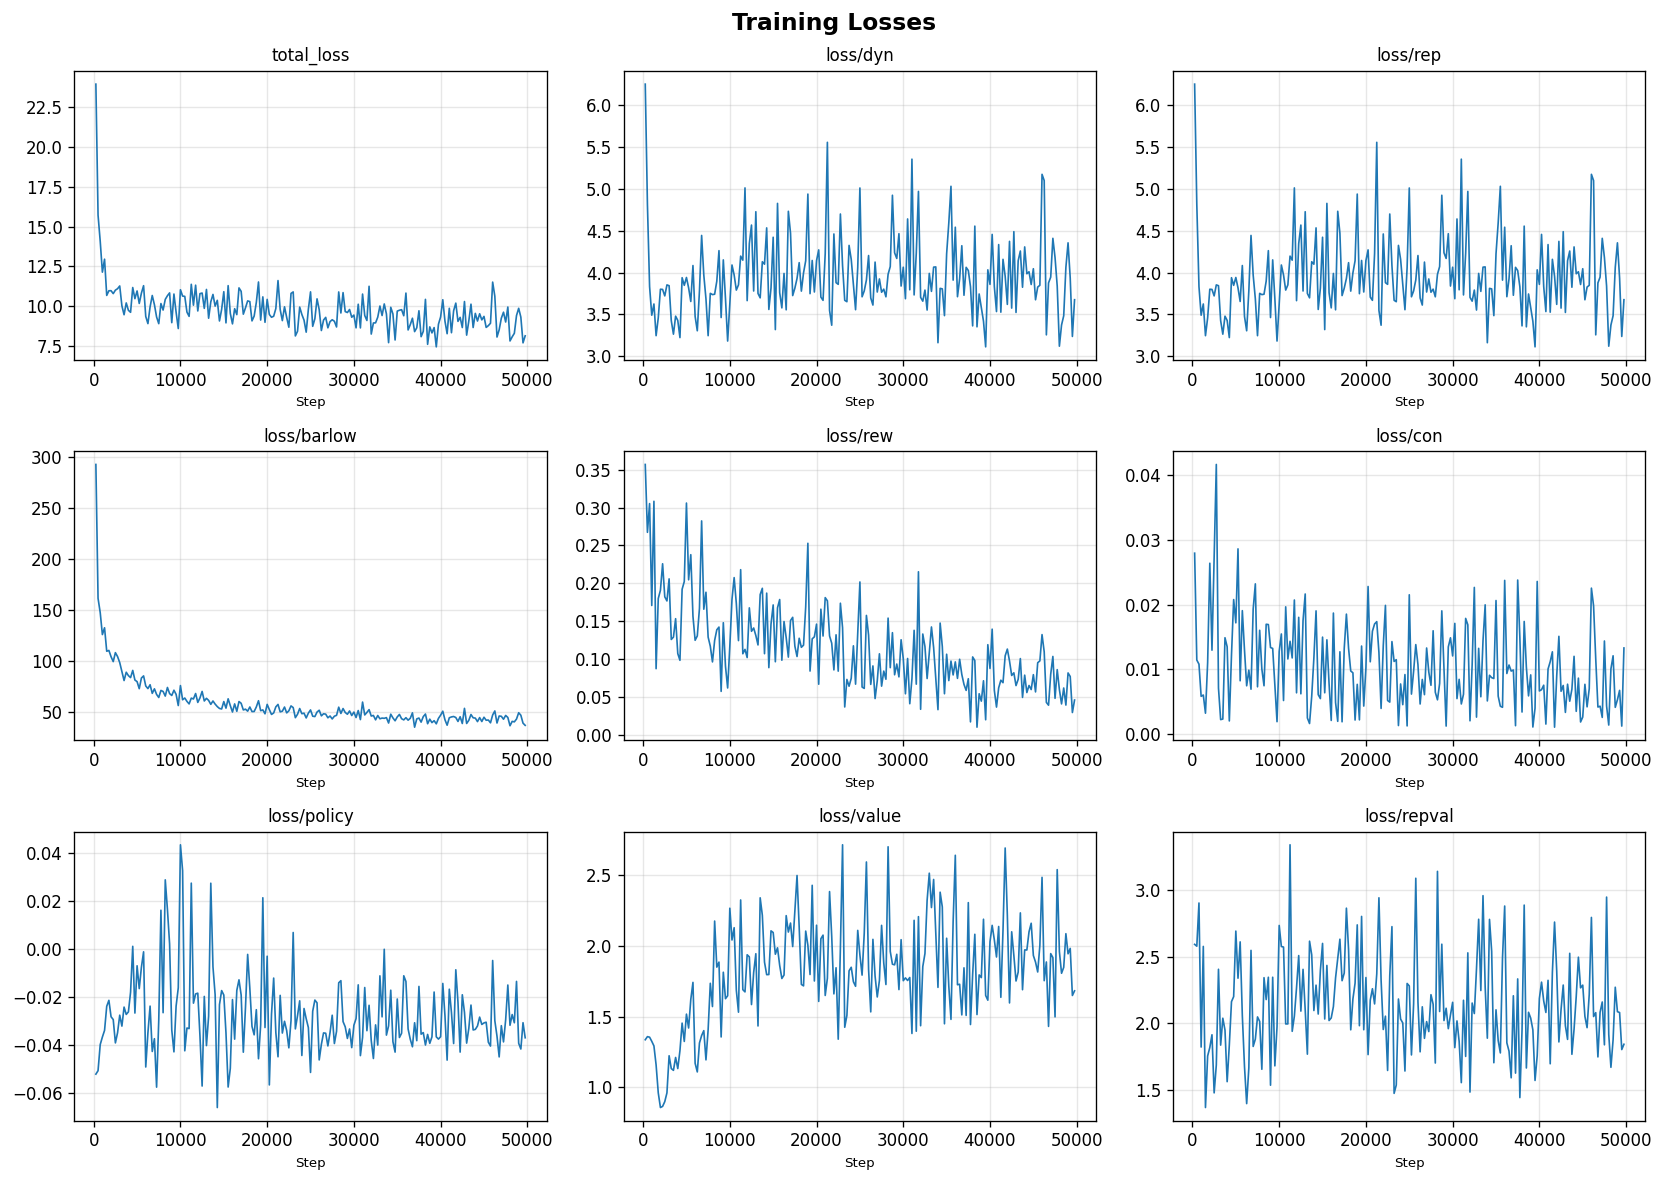

In [5]:
loss_metrics = [
    "total_loss", "loss/dyn", "loss/rep", "loss/barlow",
    "loss/rew", "loss/con", "loss/policy", "loss/value", "loss/repval",
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))

for ax, metric in zip(axes.flat, loss_metrics):
    steps, vals = extract_metric(df, metric)
    if len(steps) == 0:
        ax.set_title(f"{metric} (no data)")
        continue
    ax.plot(steps, vals, linewidth=1)
    ax.set_title(metric, fontsize=10)
    ax.set_xlabel("Step", fontsize=8)
    ax.grid(True, alpha=0.3)
    # Flag NaN/Inf
    bad = ~np.isfinite(vals)
    if bad.any():
        ax.axvline(steps[bad][0], color="red", linestyle="--", label="NaN/Inf")
        ax.legend()

fig.suptitle("Training Losses", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Summary Statistics

In [6]:
# Episode summary
_, rewards = extract_metric(df, "episode/reward")
_, successes = extract_metric(df, "episode/success")
_, spls = extract_metric(df, "episode/spl")
_, ep_steps = extract_metric(df, "episode/steps")

print(f"Total episodes: {len(rewards)}")
print(f"Reward:  mean={np.mean(rewards):.2f}  std={np.std(rewards):.2f}")
print(f"Success: {np.mean(successes)*100:.1f}%")
print(f"SPL:     {np.mean(spls):.3f}")
print(f"Steps:   mean={np.mean(ep_steps):.0f}  median={np.median(ep_steps):.0f}")

# Final training losses (last 10 logged steps)
print("\n--- Last training losses ---")
for m in loss_metrics:
    steps, vals = extract_metric(df, m)
    if len(vals) > 0:
        last = vals[-min(10, len(vals)):]
        print(f"{m:20s}: {np.mean(last):.4f}")

Total episodes: 100
Reward:  mean=0.38  std=1.57
Success: 1.0%
SPL:     0.000
Steps:   mean=499  median=500

--- Last training losses ---
total_loss          : 8.7544
loss/dyn            : 3.7249
loss/rep            : 3.7249
loss/barlow         : 42.2532
loss/rew            : 0.0574
loss/con            : 0.0073
loss/policy         : -0.0297
loss/value          : 1.8992
loss/repval         : 2.0338


## Throughput

In [7]:
# Estimate throughput from step timestamps in the CSV
# The training script logs total_loss at log_every intervals
total_steps_logged, _ = extract_metric(df, "total_loss")
if len(total_steps_logged) >= 2:
    total_env_steps = total_steps_logged[-1] - total_steps_logged[0]
    print(f"Environment steps covered by loss logs: {total_env_steps}")
    print(f"Number of log entries: {len(total_steps_logged)}")
else:
    print("Not enough data points to estimate throughput.")
    print("Check stdout/WandB for FPS numbers.")

Environment steps covered by loss logs: 49500
Number of log entries: 199
